<div style="background: linear-gradient(135deg, #1e3c72, #2a5298); 
            padding:30px; 
            border-radius:15px; 
            text-align:center; 
            box-shadow:0px 4px 15px rgba(0,0,0,0.3);">

<h1 style="color:white; 
           font-size:46px; 
           font-family:'Poppins', sans-serif; 
           letter-spacing:2px;">
Multi-Class Image Classification 

</h1>

<h3 style="color:#dbe9ff; 
           font-family:'Poppins', sans-serif;">
Using Transfer Learning with MobileNetV2

</h3>

</div>

## Import Libraries

In [38]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Data path

In [48]:
train_path = r"C:\Users\tsiha\Desktop\seg_train\seg_train"
test_path = r"C:\Users\tsiha\Desktop\seg_test\seg_test"

## Image Generator

In [49]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True)

test_gen = ImageDataGenerator(rescale=1./255)

In [50]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical')
test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical')

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [51]:
print(train_data.class_indices)

{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


## Model

In [52]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3))

C:\Users\tsiha\AppData\Local\Temp\ipykernel_15064\632844194.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


## Add Layers

In [53]:
for layer in base_model.layers:
    layer.trainable = False

In [54]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

## Compile

In [55]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [56]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 628s 1s/step - accuracy: 0.8467 - loss: 0.4281 - val_accuracy: 0.8903 - val_loss: 0.3049
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 311s 709ms/step - accuracy: 0.8809 - loss: 0.3267 - val_accuracy: 0.8950 - val_loss: 0.2822
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 310s 705ms/step - accuracy: 0.8871 - loss: 0.3064 - val_accuracy: 0.8933 - val_loss: 0.2700
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 310s 705ms/step - accuracy: 0.8900 - loss: 0.2930 - val_accuracy: 0.9013 - val_loss: 0.2676
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 309s 703ms/step - accuracy: 0.9012 - loss: 0.2725 - val_accuracy: 0.9007 - val_loss: 0.2650
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 252s 574ms/step - accuracy: 0.9022 - loss: 0.2623 - val_accuracy: 0.8953 - val_loss: 0.2892
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 238s 541ms/step - accuracy: 0.9067 - loss: 0.2529 - val_accuracy: 0.8983 - val_loss: 0.2765
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 245s 557ms/step - accuracy: 0.9067 - lo

## Accuracy plot

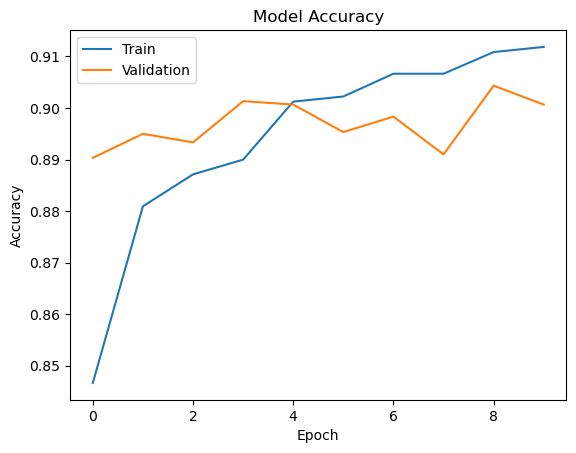

In [57]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train','Validation'])

plt.show()

## Test Accuracy

In [58]:
score = model.evaluate(test_data)

print(f"\nTest accuracy: {100.0 * score[1]:.1f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 232ms/step - accuracy: 0.9007 - loss: 0.2713

Test accuracy: 90.1%


## Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Predicted class: street


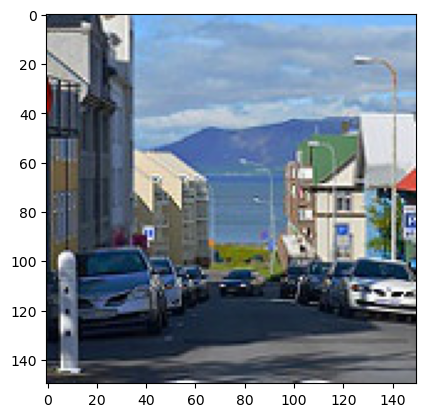

In [62]:
class_names = ['buildings','forest','glacier','mountain','sea','street']

img = image.load_img(
    r"C:\Users\tsiha\Desktop\seg_train\seg_train\street\12.jpg",
    target_size=(150,150)
)
plt.imshow(img)
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

print("Predicted class:", class_names[predicted_index])